# Tresure Maze

Questo progetto ha lo scopo di risolvere il problema posto per l'esame di intelligenze artificiale dell'università degli studi di Perugia, del corsi di laurea informatica dell'esame di introduzione all'intelligenza artificiale, sottot la cura del Professoressa V. Poggioni, per l'anno accademico 2025-2026. Il problema, data una immagine rapprensentante una griglia, ci chiede di riuscire a fornire il percorso di un agente, che seguendo le regole del problema, riesce a raccogliere tutti tesori (stato goal), rappresentati dalla cella contente il carattere 'T' seguendo il percorso del risolutore che è stato chiamato.

Il progetto è composto di **tre** parti principali: 
- la prima riguarda la creazione del modello e della creazine del dataset aggiuntivo per migliorare le performance del modello a riconoscere caratteri stampati digitalmente. 
- La seconda parte riguarda la computer vision, ovvero l'estrazione delle celle a partire da una immagine rappresentante una griglia rettangolare.
- Infine vi è la creazione e l'invocazione del risolutore:

Per la realizzazione del progetto è stato usato il linguaggio di programmazione python per le sue librerie di Machine learning. Inoltre viene usato il note book Jupyter che offre una ottima integrazione per l'inserimento di di linguaggio markdown e la possibilità di eseguire codice python a blocchi

# 1. Machine Learning

Il nostro modello ricade nell'ambito del **Supervided learning**: essendo che il data set è etichettato e ogni output ha la propria label corrispondente.

Inoltre ricadiamo nel problema della classificazione essendo che le label del nostro problema possono avere solo dei valori stabiliti.

Come Dataset utilizzato è stato usato il dataset emnist-balanced, un dataset di caratteri e numeri dove la distribuzione dei vari caratteri fra di loro è omogenea, ovvero il dataset non presenta sbilanciamento fra le classi, ogni classe rapprensenta un carattere dell'alfabeto italiano diverso in più sono forniti anche i 10 caratteri numerici, da 0 a 9.

In più sono stati aggiunti al dataset finale anche delle immagini generate artificialmente, ma a cui sono stati applicati delle funzioni di noise e di distorsione in modo tale da generare immagini sempre diverse; in modo tale da allenare il modello a riconoscere caratteri generati digitalmente.

Dal dataset è filtrato in quanto il problema richiede di riconoscere soltanto i caratteri 'S', 'T' e 'X' e caratteri corrispondenti dai numeri da 0 a 4, quindi in totale **7** caratteri da riconoscere. In maniera tale da aiutare il modello a riconoscere soltanto i caratteri intressanti al problema.

Come libreria di Machine Learning è stato utilizzato keras, importata da tensor flow

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from extra_keras_datasets import emnist
from scipy.io import loadmat

In [4]:
data = loadmat('.\emnist-balanced.mat')

# Extracting data from the loaded .mat file
x_train = data['dataset'][0][0][0][0][0][0]
y_train = data['dataset'][0][0][0][0][0][1].flatten()
x_test = data['dataset'][0][0][1][0][0][0]
y_test = data['dataset'][0][0][1][0][0][1].flatten()


# Filtering numbers and char: T,S,X
mask_train = (y_train < 5) | (y_train == 29) | (y_train == 28) | (y_train == 33)
mask_test  = (y_test < 5) | (y_test == 29) | (y_test == 28) | (y_test == 33)

x_train = x_train[mask_train]
y_train = y_train[mask_train]

x_test  = x_test[mask_test]
y_test  = y_test[mask_test]


print("numero di immagini nel training set:", x_train.shape[0])
print("numero di immagini nel test set:", x_test.shape[0])

numero di immagini nel training set: 19200
numero di immagini nel test set: 3200


### Prima di lavorare con le immagini ci assicuriamo di specchiare e di ruotare le immagini.

In [5]:
# before working with the data, we need to mirror and rotate the images
def preprocess_images(images):
    # Reshape to (num_samples, 28, 28)
    images = images.reshape((-1, 28, 28))
    # Mirror the images
    images = np.flip(images, axis=2)
    # Rotate the images by 90 degrees
    images = np.rot90(images, k=1, axes=(1, 2))
    # Flatten back to (num_samples, 784)
    images = images.reshape((-1, 784))
    return images

x_train = preprocess_images(x_train)
x_test = preprocess_images(x_test)

Eseguiamo il mapping delle etichette delle classi con la loro rappresentazione a caratteri e visualizziamo alcune di queste immagini

[4 1 3 ... 5 2 7]


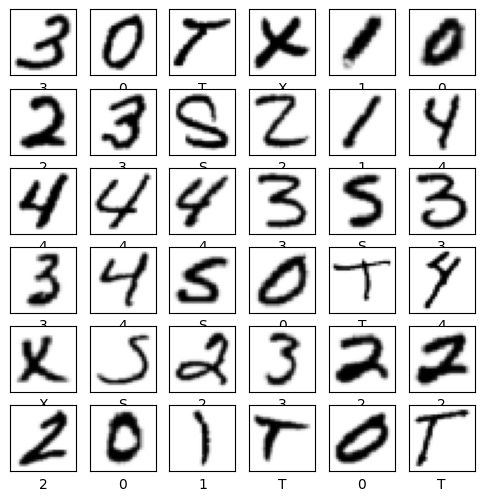

In [6]:
from matplotlib import pyplot as plt

#remapping labels to 0-7
label_mapping = {
    0:0, 1:1, 2:2, 3:3, 4:4, 
    28:5, 29:6, 33:7
}

alphabet_mapping = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: 'S', 6: 'T', 7: 'X' }

if np.any(np.isin(y_train, [28, 29, 33])):
    y_train = np.array([label_mapping[int(label)] for label in y_train])
    y_test  = np.array([label_mapping[int(label)] for label in y_test])

print(y_train)

N = x_train.shape[0]
idx = np.random.permutation(N)

plt.figure(figsize=(6,6))
for i, img in enumerate(x_train[36:72]):
    plt.subplot(6, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img.reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(alphabet_mapping[int(y_train[36 + i])])
plt.show()


Normaliziamo i dati per la rete neurale

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.00784314
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.02745098 0.1764706  0.24705882 0.00784314 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.01176471
 0.         0.         0.         0.         0.         0.
 0.         0.00784314 0.01568628 0.0352

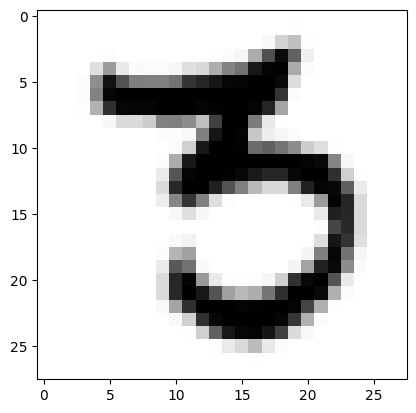

In [7]:
feature_vector_length = 28 * 28
x_train = x_train.reshape((x_train.shape[0], feature_vector_length)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], feature_vector_length)).astype('float32') / 255
print(x_test[1])
plt.imshow(x_test[1].reshape(28,28), cmap=plt.cm.binary)

### Il MLP completamente connesso è composto da: 1 layer di input, 2 layer nascosti e un layer di output finale. In totale abbiamo layer da 256, 128 e 8 neuroni (uno per ogni etichetta). Il layer di input e i layer nascosti utilizzano la funzione di attivazione "ReLU". Il modello riceve in input un vettore monodimensionale di dimensione 28×28 (il numero totale di pixel dell’immagine), che definisce la dimensione del layer di input. In questo caso, ReLU aiuta a contrastare il problema del vanishing gradient. Infine, utilizziamo softmax per ottenere la probabilità delle 8 classi.

In [8]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(feature_vector_length,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(8, activation='softmax')
])

model.summary()

c:\Users\erald\Documents\Programmazione\IA\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,888 (917.53 KB)

 Trainable params: 234,888 (917.53 KB)

 Non-trainable params: 0 (0.00 B)

### Creazione di un arresto anticipato del modello nel caso in cui il modello stia andando in overfitting. Il parametro utilizzato è la loss del validation set.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

### Ora addestriamo il modello utilizzando il training set ottenuto da EMNIST e quello personalizzato che abbiamo creato. Usiamo un massimo di 10 epoche e una batch size di 128. Per aggiornare i pesi dei neuroni utilizziamo l’ottimizzatore Adam, una versione ottimizzata dello stochastic gradient descent. Come funzione di loss utilizziamo la sparse categorical crossentropy, che calcola la perdita come $L(y,\hat{y}) = - \log({\hat{y}_{y}})$; questa funziona molto bene quando l’etichetta corretta può essere una sola e le etichette fornite sono interi

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# history = model.fit(combined_X_train, combined_y_train, epochs=10 ,batch_size=128, validation_split=0.1, callbacks=[early_stop])
history = model.fit(x_train, y_train, epochs=10 ,batch_size=128, validation_split=0.1, callbacks=[early_stop])


Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9065 - loss: 0.3302 - val_accuracy: 0.9557 - val_loss: 0.1407
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9680 - loss: 0.1134 - val_accuracy: 0.9661 - val_loss: 0.1108
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9797 - loss: 0.0735 - val_accuracy: 0.9745 - val_loss: 0.0762
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9860 - loss: 0.0500 - val_accuracy: 0.9776 - val_loss: 0.0713
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9909 - loss: 0.0318 - val_accuracy: 0.9812 - val_loss: 0.0674
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0233 - val_accuracy: 0.9792 - val_loss: 0.0681
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9958 - loss: 0.0154 - val_accuracy: 0.9734 - val_loss: 0.0806
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9968 - loss: 0.0136 - val_accuracy: 0.

100/100 - 0s - 1ms/step - accuracy: 0.9803 - loss: 0.0834

Test accuracy: 0.9803125262260437


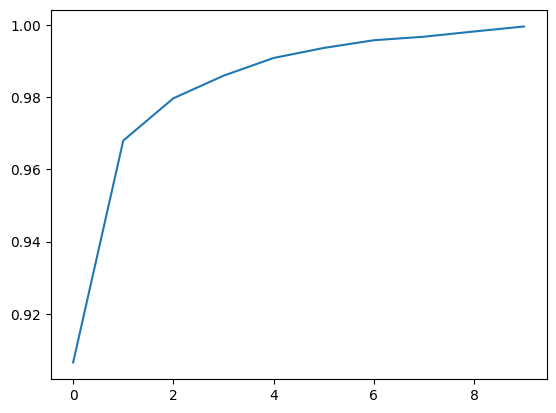

In [11]:
# mopdel evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)
# plotting training history
plt.plot(history.history['accuracy'], label='accuracy')

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step


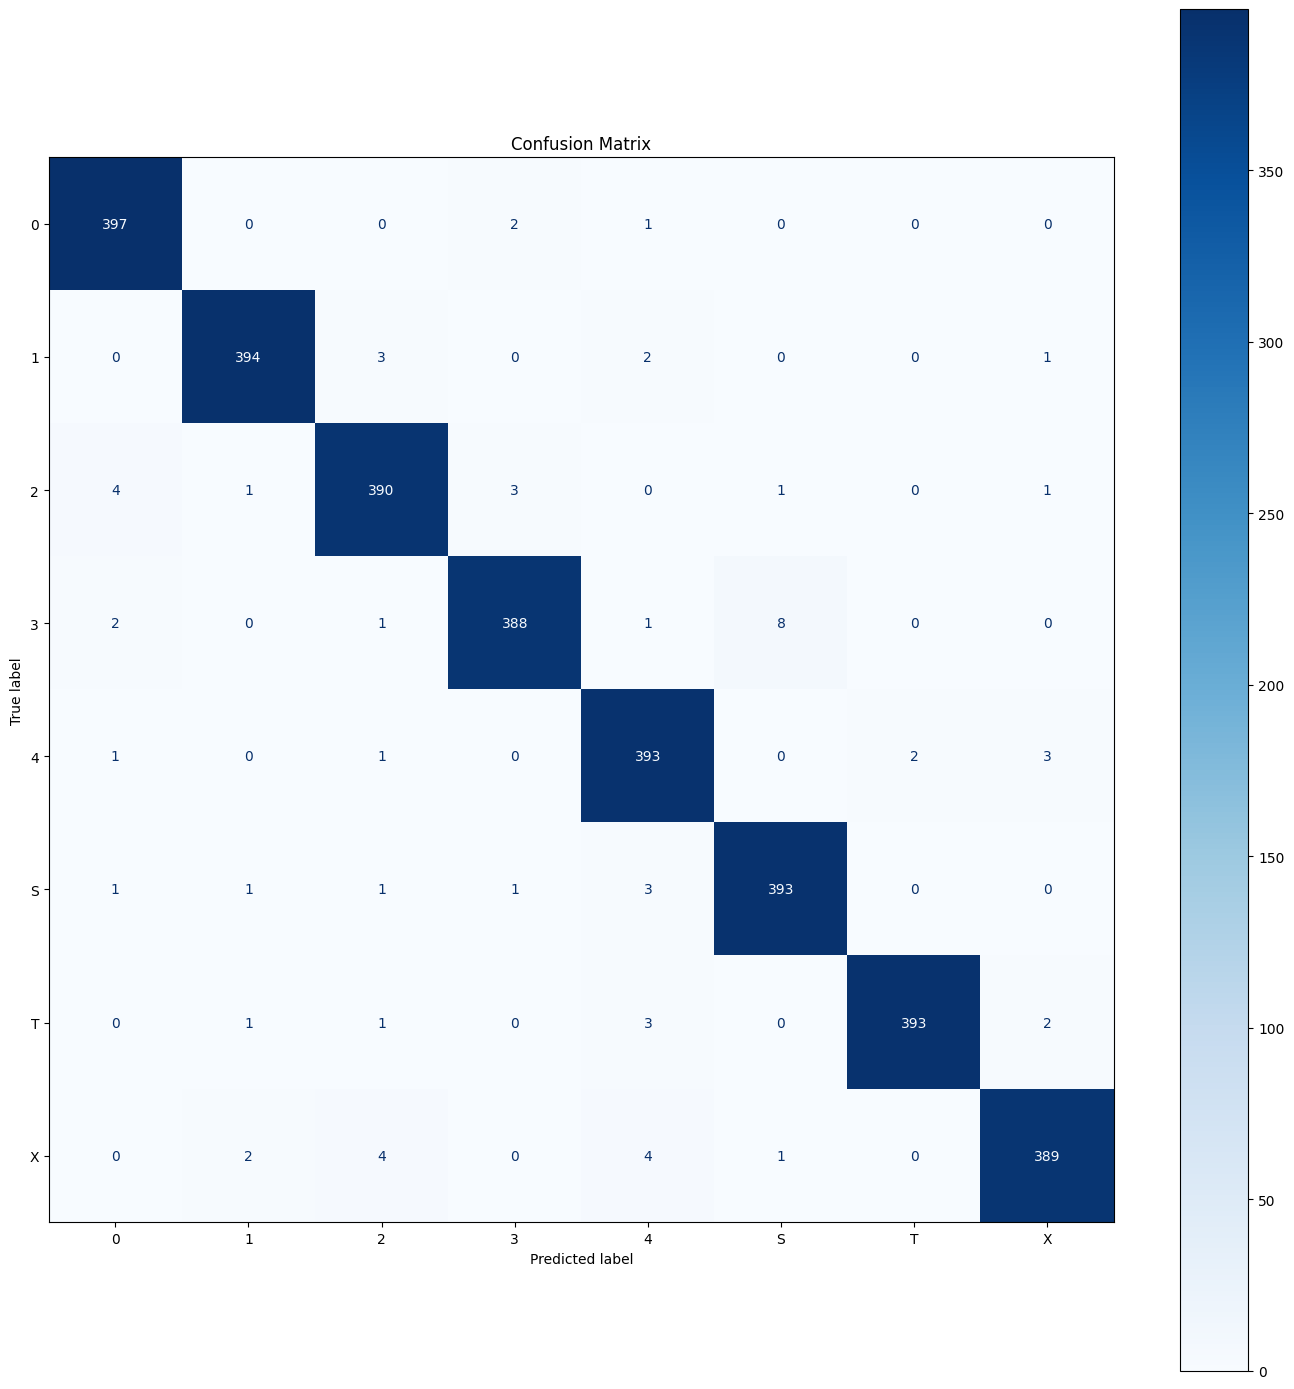

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       400
           1       0.99      0.98      0.99       400
           2       0.97      0.97      0.97       400
           3       0.98      0.97      0.98       400
           4       0.97      0.98      0.97       400
           S       0.98      0.98      0.98       400
           T       0.99      0.98      0.99       400
           X       0.98      0.97      0.98       400

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200



In [12]:
# plotting the confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(14, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
    plt.title('Confusion Matrix')
    plt.tight_layout() 
    plt.show()

plot_confusion_matrix(cm, labels=alphabet_mapping.values())
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes,
                            target_names=list(alphabet_mapping.values())))

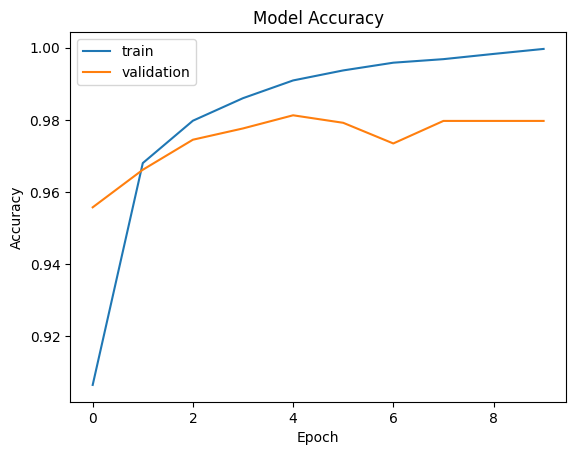

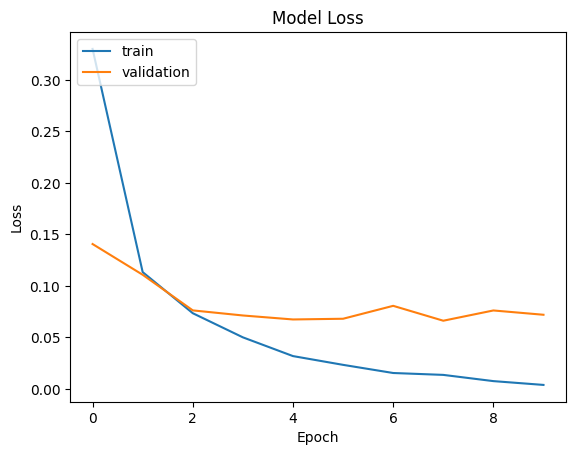

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [14]:
score = model.evaluate(x_test, y_test, verbose=False)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.0834110826253891
Test accuracy: 0.9803125262260437


## Now we use OpenCV library to extract the cells inside the grid, since the grid be can be created both by and or using softwares, many techniques has been used.

### The pipeline of this part its as follows:
- We read the image, we convert it as a gray scale image and we pass it to a preprocess function.
- The preprocess function does some manipulation on the image:
    - We do a gaussian blur, adaptiveThreshold and at the end medianblur in order to add some blur and remove possible imperfections
- We determine the horizontal and vertial lines from the image using morphological operation and we return the two images that cointains such structures.
- The 2 images rapresenting the vertical and horizontal lines are passed to combine_pos function; It combines 2 other function to get the points that represents the lines of the grid. After this we order and remove the gap in order to get a more accurate view of the points and the segments we get.
- After obtaining those information we check, through refine_line_from_intersection if we can fit a segments that can intersect through the points we get.

After getting the lines we crop the images in to small cells that should represent our grid, after that and we save them.

In [15]:
import cv2
import os
from pathlib import Path

In [16]:
def preprocess_image(gray, use_niBlack=False):
    image = cv2.GaussianBlur(gray, (5, 5), 0)
    '''
    If niBlackThreshold is not available, we fall back to adaptiveThreshold with Gaussian 
    method. Which is a common choice for binarizing images with varying 
    illumination, but may not be as robust as niBlackThreshold for hand-drawn grids
    with inconsistent line quality.
    We use parameters (blockSize=31, C=8).
    '''
    image = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 8)
    # We apply a median blur to reduce noise and smooth the edges of the grid lines,
    # which can help in better contour detection later on.
    image = cv2.medianBlur(image, 3)
    return image

In [17]:
def hor_ver_lines(image):
    '''
    This function extracts horizontal and vertical lines from the preprocessed binary image using morphological operations.
        - We first determine the kernel sizes for horizontal and vertical line detection based on the image dimensions
        - We create horizontal and vertical kernels using cv2.getStructuringElement
        - We apply morphological opening to extract horizontal and vertical lines separately
        - We then apply morphological closing to fill small gaps in the detected lines, which can help in creating more continuous line masks for better contour detection later on.
    The resulting hmask and vmask are binary images where the detected horizontal and vertical lines are highlighted, respectively. 
    '''
    h, w = image.shape
    hk = max(15, w//18)  # Kernel size for horizontal lines, adjusted based on image width
    vk = max(15, h//18)  # Kernel size for vertical lines,

    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (hk, 1)) # Create a horizontal kernel for morphological operations
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vk)) # Create a vertical kernel for morphological operations

    close_h = cv2.getStructuringElement(cv2.MORPH_RECT, (max(5, hk // 4),1)) # Kernel for closing small gaps in horizontal lines
    close_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(5, vk // 4))) # Kernel for closing small gaps in vertical lines

    hmask = cv2.morphologyEx(image, cv2.MORPH_OPEN, horizontal_kernel) # Extract horizontal lines using morphological opening
    vmask = cv2.morphologyEx(image, cv2.MORPH_OPEN, vertical_kernel) # Extract vertical lines using morphological opening
    hmask = cv2.morphologyEx(hmask, cv2.MORPH_CLOSE, close_h) # Close small gaps in horizontal lines
    vmask = cv2.morphologyEx(vmask, cv2.MORPH_CLOSE, close_v) # Close small gaps in vertical lines
    return hmask, vmask

In [18]:
def project_position(mask, orientation='h'):
    '''
    This function counts the number of pixels through each row (for horizontal) or column (for vertical) of the mask,
    Similarly to Hough that searches for lines, we look also for non perfect lines.
    '''
    if orientation == 'h':
        proj = (mask > 0).sum(axis=1)  # Count non-zero pixels in each row for horizontal lines
        limit = mask.shape[1] # we set the limit to the width of the image, so we can later check if the count of pixels is close enough to the width to consider it a line
    else:
        proj = (mask > 0).sum(axis=0)  # Count non-zero pixels in each column for vertical lines
        limit = mask.shape[0] # the limit is the height of the image for vertical lines

    thr = max(10, int(limit * 0.15)) # we set a threshold to consider a line, it can be adjusted based on the expected line thickness and quality
    idx = np.where(proj > thr)[0].tolist() # we get the indices of the rows or columns that have a count of pixels above the threshold, which indicates the presence of a line
    return idx

In [19]:
def detect_line_pos(mask, orientation='h', angle_tol=18, min_length_ratio=0.2, max_gap=25):
    '''
    This function detects the positions of lines in the mask using HoughLinesP, which can find line segments even if they are not perfectly straight or continuous.
    We use the parameters angle_tol, min_length_ratio, and max_gap to filter the detected lines based on their angle, length, and continuity, which helps in improving the accuracy of line detection in hand-drawn grids.
    The function returns a list of coordinates (either y-coordinates for horizontal lines or x-coordinates for vertical lines) and a list of the kept line segments with their properties (endpoints and length). 
    '''
    h, w = mask.shape
    min_len = int((w if orientation == 'h' else h) * min_length_ratio) # we set a minimum length for the lines to be considered valid, based on a ratio of the image dimensions
    lines = cv2.HoughLinesP(mask, 1, np.pi / 180, threshold=40,
                            minLineLength=max(20, min_len),
                            maxLineGap=max_gap) # we use HoughLinesP to detect line segments in the mask, with parameters that can be adjusted based on the expected line quality and spacing
    coords = [] # list that will hold the coordinates of the detected lines
    if lines is None:
        return coords, []
    kept = [] # list that will hold the lines that are kept after filtering based on angle and length
    for line in lines[:, 0, :]:
        x1, y1, x2, y2 = map(int, line) # we extract the coordinates of the endpoints of the line segment
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) # we calculate the angle of the line segment to filter out lines that are not close to horizontal or vertical
        length = float(np.hypot(x2 - x1, y2 - y1)) # we calculate the length of the line segment to filter out short lines that are likely noise
        if orientation == 'h': 
            if abs(angle) <= angle_tol or abs(abs(angle) - 180) <= angle_tol:
                coords.append((y1+y2)/2)
                kept.append((x1, y1, x2, y2, length)) # if the line is close to horizontal, we keep its coordinates and properties
        else: 
            if abs(abs(angle) - 90) <= angle_tol:
                coords.append((x1+x2)/2)
                kept.append((x1, y1, x2, y2, length)) # if the line is close to vertical, we keep its coordinates and properties
    return coords, kept 

In [20]:
def order_points(vals, min_gap=12):
    '''
    This function takes a list of coordinates (both for horizontal and vertical lines)
    and orders them while removing duplicates that are too close to each other.
    We first sort the coordinates, so we can check if they are close enough to be considered
    the same line, and if not we keep them in the ordered list.
    The function return a list of the mean coordinates of the groups of close lines,
    which represent the final line positions.
    '''
    vals = sorted(int(v) for v in vals) # we sort the coordinates.
    if not vals:
        return []
    groups = [[vals[0]]] # we create a list of lists to hold the groups of coordinates that are close to each other
    for v in vals[1:]:
        if abs(v-groups[-1][-1]) <= min_gap: # if the current coordinate is close enough to the last coordinate of the last group, we add it to that group
            groups[-1].append(v) 
        else:
            groups.append([v]) # if not, we start a new group with the current coordinate
    
    return [int(round(np.mean(g))) for g in groups] # we return a list of the mean coordinates of each group, which represent the final ordered and filtered line positions

In [21]:
def remove_border_pos(vals, limit, margin_ratio=0.01):
    '''
    This function removes lines that are too close to the borders of the image,
    as they are likely to be noise or incomplete lines.
    '''
    margin = max(3, int(limit * margin_ratio)) # we calculate a margin based on the image dimensions, with a minimum of 3 pixels, to determine how close to the borders we consider lines to be noise
    return [v for v in vals if margin <= v <= limit - margin] # we keep only the coordinates that are within a certain margin from the borders of the image, which can be adjusted based on the expected line quality and spacing


In [22]:
def combine_pos(mask, orientation='h'):
    '''
    This function takes the image that represents the lines (either horizontal or vertical)
    and processes it to find the positions of the lines.
    It uses the detect_line_pos function to identify the line positions and segments,
    which are then used to determine the grid structure using HoughLinesP.
    It also uses the project_position function to find additional line positions based on the projection of the line pixels.
    Finally, it combines the positions found by both methods, orders them, and removes any that are too close to the borders of the image.
    We return the final list of line positions and the segments detected by HoughLinesP, which can be used for further processing to determine the grid structure and cell boundaries.
    '''
    h, w = mask.shape
    hough_pos, segments = detect_line_pos(mask, orientation=orientation,
                                          min_length_ratio=0.15,
                                          max_gap = max(20 , 
                                                       int((w if orientation == 'h' else h) * 0.03))) 
    proj_pos = project_position(mask, orientation=orientation)
    raw = hough_pos + proj_pos
    if not raw:
        return [], segments
    merged = order_points(raw, min_gap=max(10, int((h if orientation == 'h' else w) * 0.015)))
    merged = remove_border_pos(merged, h if orientation == 'h' else w)
    return merged, segments

In [23]:
def refine_line_from_intersection(h_lines, v_lines, hmask, vmask, support=3):
    '''
    This function takes the detected horizontal and vertical line positions, and the corresponding masks.
    It checks for each horizontal line if there are at least 2 vertical lines that intersect it within a certain support area.
    Returns the refined list of horizontal and vertical line positions that are likely to be part of the same grid structure,
    based on the presence of line pixels in the area around the intersection of the horizontal and vertical lines.
    '''
    # Horizontal lines
    refined_h = []
    for y in h_lines:
        count = 0
        for x in v_lines:
            y1 = max(0, y - support)
            y2 = min(hmask.shape[0], y + support + 1)
            x1 = max(0, x - support)
            x2 = min(hmask.shape[1], x + support + 1)
            if hmask[y1:y2, x1:x2].any() or vmask[y1:y2, x1:x2].any(): # we check if there is any line pixel in the area around the intersection of the horizontal and vertical lines, which indicates that they are likely to be part of the same grid structure
                count += 1
        if count >= 2:
            refined_h.append(y)
    # Vertical lines
    refined_v = []
    for x in v_lines:
        count = 0
        for y in h_lines:
            y1 = max(0, y - support)
            y2 = min(vmask.shape[0], y + support + 1)
            x1 = max(0, x - support)
            x2 = min(vmask.shape[1], x + support + 1)
            if hmask[y1:y2, x1:x2].any() or vmask[y1:y2, x1:x2].any():
                count += 1
        if count >= 2:
            refined_v.append(x)
    return refined_h, refined_v

In [24]:
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

In [25]:
def crop_cells(gray, h_lines, v_lines, out_dir, inner_margin=8, min_size=12):
    '''
    This function takes the grayscale image, the detected horizontal and vertical line positions, and an output directory.
    It iterates through the grid defined by the horizontal and vertical lines, and for each cell defined by the intersection of the lines, it crops the corresponding area from the grayscale image.
    We apply an inner margin to avoid including the grid lines in the cropped cell images, and we check if the resulting cell is above a minimum size to filter out very small cells that are likely to be noise or incomplete.
    The cropped cell images are resized to a standard size (28x28) format, and saved to the specified output directory with a naming convention that indicates their row and column position in the grid. The function returns a list of tuples containing the row and column indices, the coordinates of the cropped cell, and the filename of the saved cell image, which can be used for further
    processing or analysis of the extracted cell images.
    '''
    ensure_dir(out_dir)
    cells = []
    idx = 0
    for i in range(len(h_lines) - 1):
        for j in range(len(v_lines) - 1):
            y1, y2 = h_lines[i], h_lines[i + 1]
            x1, x2 = v_lines[j], v_lines[j + 1]
            top = max(0, y1 + inner_margin)
            bottom = min(gray.shape[0], y2 - inner_margin)
            left = max(0, x1 + inner_margin)
            right = min(gray.shape[1], x2 - inner_margin)
            if bottom - top < min_size or right - left < min_size:
                continue
            # print(f"Cropping cell at row {i}, column {j}: ({left}, {top}) to ({right}, {bottom})")
            cell = gray[top:bottom, left:right]
            cell = cv2.resize(cell, (28, 28), interpolation=cv2.INTER_AREA)
            name = f"cell_r{i:02d}_c{j:02d}.png"
            cv2.imwrite(str(Path(out_dir) / name), cell)
            cells.append((i, j, left, top, right, bottom, name))
            idx += 1
    return cells

## After we extract the cells, we perform some operation in order to give them to the model as similar as ther images from the dataset.

In [26]:
import glob
def zoom_and_preprocess(cell_gray, pad=2, out_size=28, blur_sigma=1.0, edge_width=11.0):
    '''
    This function takes a grayscale image of a cell, applies padding, and preprocesses it to enhance the character inside the cell for better recognition.
    The steps include:
    1) Thresholding the image to create a binary mask of the character, which helps in isolating the character from the background and grid lines.
    2) Finding the bounding box of the character based on the binary mask, which allows us to crop the character more tightly and reduce the amount of background noise.
    3) Creating a canvas to place the cropped character, which helps in centering the character and providing a consistent input size for recognition.
    4) Resizing the canvas to a standard output size (28x28), which is commonly used for character recognition models.
    5) Applying a Gaussian blur to the resized image to create a blended version that can help in smoothing the edges of the character, while keeping the original grayscale image for the internal details.
    6) Using a distance transform to create an alpha mask that gives higher values near the edges of the character and lower values towards the center, which allows us to blend the blurred version with the original grayscale image in a way that preserves the internal details of the character while softening the edges, which can improve recognition performance by reducing noise and enhancing the character's shape.
    Finally, the function returns the processed image and a flattened vector of the pixel values normalized to the range [0, 1], which can be used as input for a character recognition model.
    '''
     # 1) thresholding to create a binary mask of the character, which helps in isolating the character from the background and grid lines
    _, th = cv2.threshold(cell_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    fg_mask = 255 - th  # carattere bianco su sfondo nero

    ys, xs = np.where(fg_mask > 0)
    if len(xs) == 0:
        out = np.zeros((out_size, out_size), dtype=np.uint8)
        return out, (out.astype(np.float32) / 255.0).flatten()

    # 2) finding the bounding box of the character based on the binary mask
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    #  crop dalla grayscale originale invertita --- we crop the character from the original grayscale image, inverting it to have the character as white on a black background, which can help in enhancing the character's features during the subsequent processing steps.
    glyph_gray = 255 - cell_gray[y1:y2+1, x1:x2+1]
    glyph_mask = fg_mask[y1:y2+1, x1:x2+1]

    h, w = glyph_gray.shape
    side = max(h, w) + 2 * pad

    canvas_gray = np.zeros((side, side), dtype=np.uint8)
    canvas_mask = np.zeros((side, side), dtype=np.uint8)

    oy = (side - h) // 2
    ox = (side - w) // 2
    canvas_gray[oy:oy+h, ox:ox+w] = glyph_gray
    canvas_mask[oy:oy+h, ox:ox+w] = glyph_mask

    # 3) resize
    gray28 = cv2.resize(canvas_gray, (out_size, out_size), interpolation=cv2.INTER_AREA)
    mask28 = cv2.resize(canvas_mask, (out_size, out_size), interpolation=cv2.INTER_NEAREST)

    # 4) blurring the grayscale version to create a blended image that can help in smoothing the edges of the character, while keeping the original grayscale image for the internal details.
    blurred = cv2.GaussianBlur(gray28, (0, 0), sigmaX=0.8)

    # 5) distance transform inside the character to create an alpha mask that gives higher values near the edges of the character and lower values towards the center, which allows us to blend the blurred version with the original grayscale image in a way that preserves the internal details of the character while softening the edges, which can improve recognition performance by reducing noise and enhancing the character's shape.
    mask_bin = (mask28 > 0).astype(np.uint8)
    dist = cv2.distanceTransform(mask_bin, cv2.DIST_L2, 3)

    alpha = np.clip((edge_width - dist) / edge_width, 0.0, 1.0)

    # 6) blending the blurred version with the original grayscale image using the alpha mask, which allows us to preserve the internal details of the character while softening the edges, improving recognition performance by reducing noise and enhancing the character's shape.
    out = gray28.astype(np.float32) * (1.0 - alpha) + blurred.astype(np.float32) * alpha

    out[mask_bin == 0] = 0

    # we normalize the output image to the range [0, 255] and convert it to uint8 format, which is suitable for saving or further processing. We also create a flattened vector of the pixel values normalized to the range [0, 1], which can be used as input for a character recognition model.
    if out.max() > out.min():
        out = (out - out.min()) / (out.max() - out.min()) * 255.0

    out = out.astype(np.uint8)
    vec = out.astype(np.float32) / 255.0
    return out, vec.flatten()

### Now we make the prediction of the extracted images with the model and we save the result in 2D list.

In [27]:
img = cv2.imread("./grid.png", cv2.IMREAD_GRAYSCALE)
print("Original image shape:", img.shape)
img_preprocessed = preprocess_image(img, use_niBlack=False)
hmask, vmask = hor_ver_lines(img_preprocessed)
h_lines, h_segments = combine_pos(hmask, orientation='h')
v_lines, v_segments = combine_pos(vmask, orientation='v')
h_lines, v_lines = refine_line_from_intersection(h_lines, v_lines, hmask, vmask)
cells = crop_cells(img, h_lines, v_lines, out_dir="./cells", inner_margin=8, min_size=12)
print(f"Detected {len(cells)} cells.")

Original image shape: (544, 565)
Detected 49 cells.


In [28]:
folder = r'.\cells'
paths = sorted(glob.glob(os.path.join(folder, '*.png')))

kernel = np.array([[0,1,0],
                  [0,1,0],
                  [0,0,0]], np.uint8)

X = []
imgs_show = []  
names = []

for p in paths:
    cell = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if cell is None:
        continue

    img_zoomed, _ = zoom_and_preprocess(cell)

    if img_zoomed.dtype != np.uint8:
        img_u8 = (img_zoomed * 255).astype('uint8')
    else:
        img_u8 = img_zoomed

    img_thick = cv2.dilate(img_zoomed, kernel, iterations=1)

    img_norm = img_thick.astype('float32') / 255.0

    imgs_show.append(img_norm)           
    X.append(img_norm.flatten())
    names.append(os.path.basename(p))

X = np.array(X, dtype='float32')         # (N, 784)
imgs_show = np.array(imgs_show)         # (N, 28, 28)
print("X shape:", X.shape)

X shape: (49, 784)


In [29]:
# now apply the same preprocessing to the cropped cells and prepare the data for the model
for cell in cells:
    img = cv2.imread(str(Path("./cells") / cell[6]), cv2.IMREAD_GRAYSCALE)
    img_zoomed, _ = zoom_and_preprocess(img)
    if img_zoomed.dtype != np.uint8:
        img_u8 = (img_zoomed * 255).astype('uint8')
    else:
        img_u8 = img_zoomed
    img_thick = cv2.dilate(img_zoomed, kernel, iterations=1)
    img_norm = img_thick.astype('float32') / 255.0
    img_norm = 1.0 - img_norm    # inversion for the image to be EMNIST-like


## Now the model makes the predictions

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


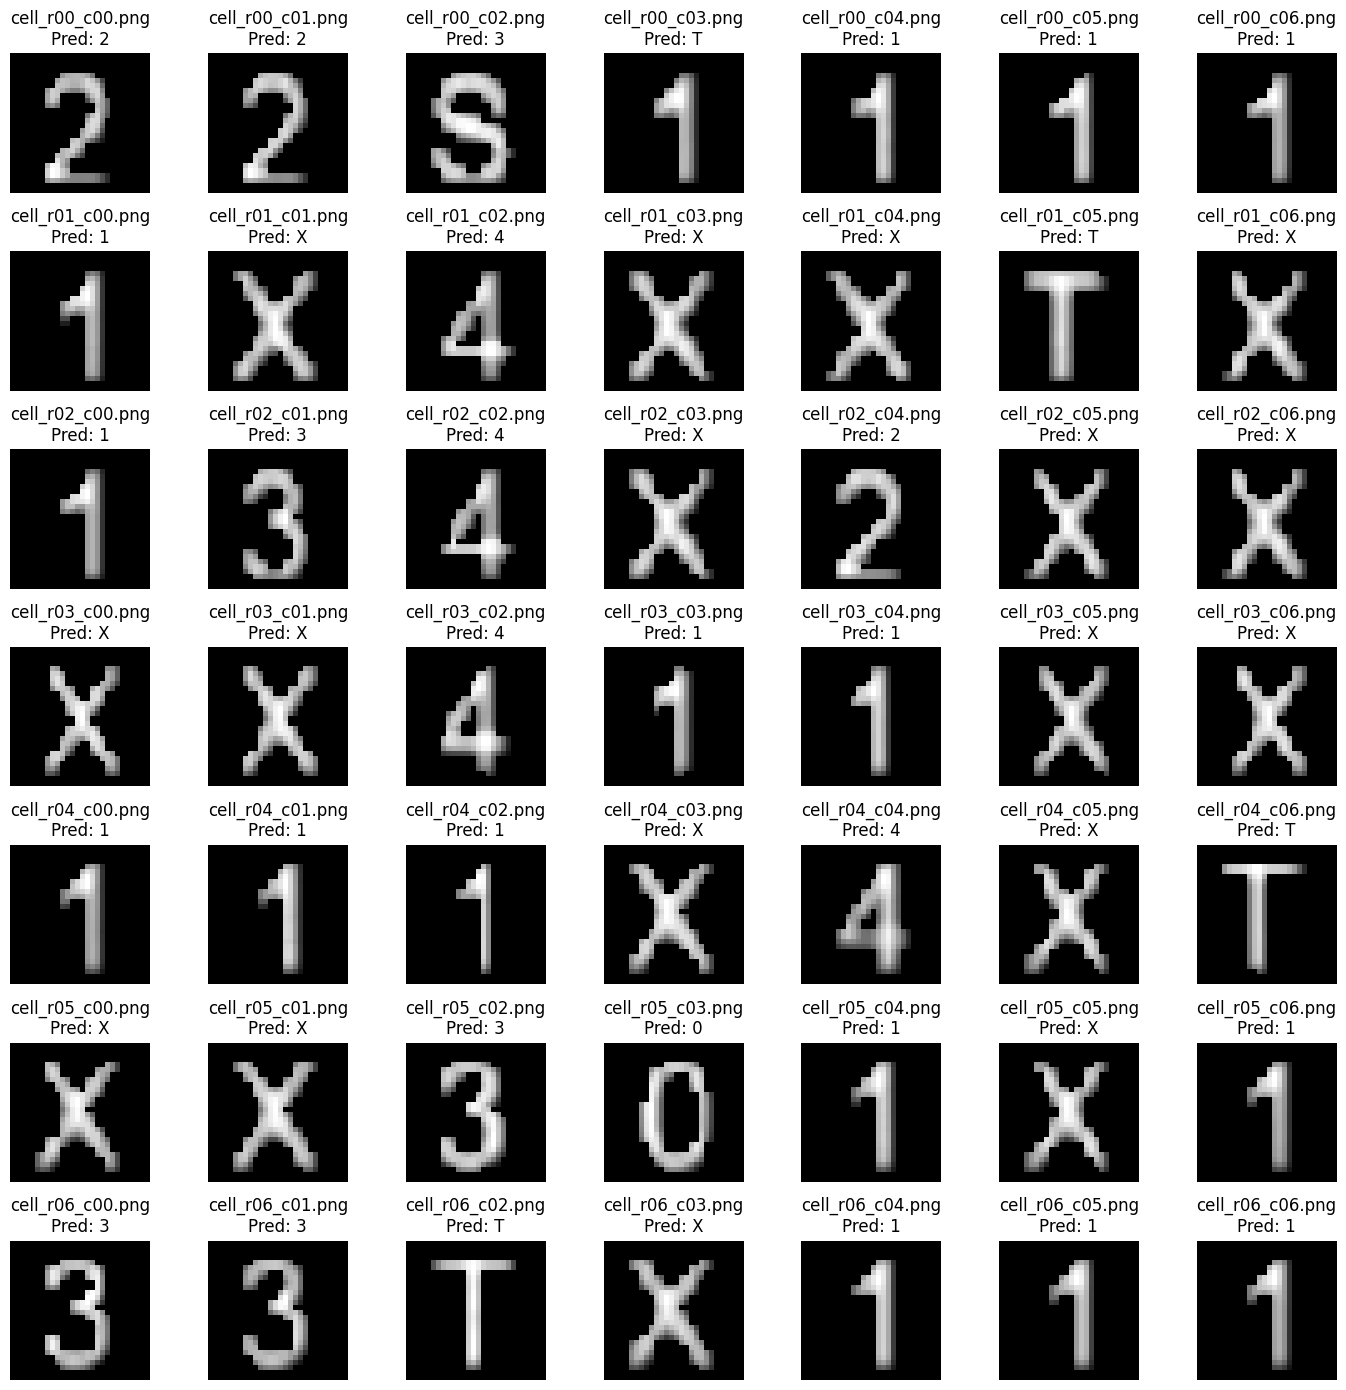

In [30]:
# predizione con il modello MLP EMNIST
probs = model.predict(X)
y_pred = np.argmax(probs, axis=1)

N = len(imgs_show)
cols = len(h_lines) - 1
rows = len(v_lines) - 1

plt.figure(figsize=(2*cols, 2*rows))

for i in range(N):
    character = alphabet_mapping[y_pred[i]]
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs_show[i], cmap='gray')
    plt.title(f"{names[i]}\nPred: {character}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [31]:
# save the results in a numpy array
results = np.zeros((len(y_pred)))
for i in range(len(y_pred)):
    results[i] = y_pred[i]

print(results.shape)

(49,)


In [49]:
# convert the results in a list of characters
results_list = []
for i in range(len(y_pred)):
    results_list.append(alphabet_mapping[y_pred[i]])
print(results_list)

# convert the results in 2D list
results = []
for i in range(rows):
    row = []
    for j in range(cols):
        idx = i * cols + j
        if idx < len(y_pred):
            row.append(alphabet_mapping[y_pred[idx]])
        else:
            row.append('')
    results.append(row)
print("Results in 2D list:")
print(results)

start = None
# find the start where the character is 'S'
for i in range(len(results)):
    for j in range(len(results[i])):
        if results[i][j] == 'S':
            start = (i, j)
            print("Start found at:", start)
if not start:
    print("Start character 'S' not found in the results.")
    start_input = input('Insert the start position as row,col (e.g., 0,0): ')
    start = tuple(map(int, start_input.split(',')))
    results[start[0]][start[1]] = 'S'

['2', '2', '3', 'T', '1', '1', '1', '1', 'X', '4', 'X', 'X', 'T', 'X', '1', '3', '4', 'X', '2', 'X', 'X', 'X', 'X', '4', '1', '1', 'X', 'X', '1', '1', '1', 'X', '4', 'X', 'T', 'X', 'X', '3', '0', '1', 'X', '1', '3', '3', 'T', 'X', '1', '1', '1']
Results in 2D list:
[['2', '2', '3', 'T', '1', '1', '1'], ['1', 'X', '4', 'X', 'X', 'T', 'X'], ['1', '3', '4', 'X', '2', 'X', 'X'], ['X', 'X', '4', '1', '1', 'X', 'X'], ['1', '1', '1', 'X', '4', 'X', 'T'], ['X', 'X', '3', '0', '1', 'X', '1'], ['3', '3', 'T', 'X', '1', '1', '1']]
Start character 'S' not found in the results.


# Research part

In [50]:
from aima.search import Problem, Node, memoize, PriorityQueue
from aima.search import depth_first_graph_search, breadth_first_graph_search, iterative_deepening_search, depth_limited_search
from collections.abc import Callable
import time

In [51]:
# Colori da usare nella print()
BLUE = "\033[34;1m"
RED = "\033[31;1m"
GREEN = "\033[32;1m"
RESET = "\033[0m"

In [ ]:
from dataclasses import dataclass
from sre_parse import State
from typing import FrozenSet, Tuple

@dataclass(frozen=True)
class AgentState:
    col: int
    row: int
    treasures: FrozenSet[Tuple[int, int]]
    broken_walls: FrozenSet[Tuple[int, int]]

    def __repr__(self):
        return f"AgentState(col={self.col}, row={self.row}, treasures={self.treasures}, broken_walls={self.broken_walls})"
    

class GridTreasure(Problem): 
    def __init__(self, initial: AgentState, grid, required_treasures='max'):
        super().__init__(initial)
        self.grid = grid                                                      # Grid representation as a list of lists
        self.n = len(grid)                                                    # number of rows
        self.m = len(grid[0])                                                 # number of columns
        self.required_treasures = self.count_treasures(required_treasures)    # number of treasures in the grid
        self.treasure_to_collect = required_treasures                         # number of treasures to collect
        self.start_col, self.start_row = self.find_start()                    # find the starting position of 'S'

    # function to find the starting position 'S' in the grid
    def find_start(self):
        for r in range(self.n):
            for c in range(self.m):
                if self.grid[r][c] == 'S':
                    return c, r
        raise ValueError("Start position 'S' not found in the grid")

    # function return the number of treasures in the grid, if required is 'max' we count all the treasures, otherwise we return the minimum between the required and the number of treasures in the grid
    def count_treasures(self, required):
        if required == 'max':
            required = 0
            for r in range(self.n):
                for c in range(self.m):
                    if self.grid[r][c] == 'T':
                        required += 1
            return required
        else: 
            T = 0
            for r in range(self.n):
                for c in range(self.m):
                    if self.grid[r][c] == 'T':
                        T += 1
            if required > T:
                return T
            return required

    # goal is reached when the number of collected treasures equals the required number
    def goal_test(self, s: AgentState):
        return len(s.treasures) == self.required_treasures

    # function to count the number of treasures 'T' in the grid
    def treasure_number(self):
        treasures = 0
        for r in range(self.n):
            for c in range(self.m):
                if self.grid[r][c] == 'T':
                    treasures += 1
        return treasures
    
    def cell_cost(self, r, c, state):
        cell = self.grid[r][c]

        if cell in {'S', '0', 'T'}:
            return 0
        elif cell in {'1', '2', '3', '4'}:
            return int(cell)
        elif cell == 'X':
            return 1 if (r, c) in state.broken_walls else 5

        raise ValueError(f"Unknown cell type: {cell}")
    
    # possible actions are the valid moves (left, right, up, down)
    def actions(self, s: State):
        moves = []
        for name, dc, dr in [('left', -1, 0), ('right', 1, 0), ('up', 0, -1), ('down', 0, 1)]:  # direction vectors
            new_col = s.col + dc
            new_row = s.row + dr
            if 0 <= new_col < self.m and 0 <= new_row < self.n: # check bounds
                moves.append(name)
        return moves
    
    # result of an action is the new state after moving in the specified direction and collecting any treasure if present
    def result(self, s: State, move: str):
        dc, dr = {'left': (-1, 0), 'right': (1, 0), 'up': (0, -1), 'down': (0, 1)}[move]

        new_col = s.col + dc
        new_row = s.row + dr

        cell = self.grid[new_row][new_col]

        collected_treasures = set(s.treasures) # create a mutable copy of the collected treasures
        broken_walls = set(s.broken_walls)         # create a mutable copy of the broken walls

        if cell == 'T':
            collected_treasures.add((new_row, new_col))
        elif cell == 'X':   
            broken_walls.add((new_row, new_col))

        return AgentState(new_col, new_row, frozenset(collected_treasures), frozenset(broken_walls))
    
    # the cost of a path is the sum of the costs of the cells visited, including the cost of breaking walls and collecting treasures
    def path_cost(self, c, s1, a, s2):
        return c + self.cell_cost(s2.row, s2.col, s1) # cost of the new cell after the move

In [53]:

@dataclass
class Result:
    node: Node
    nodes_expanded: int
    explored_size: int
    frontier_size: int

def best_first_graph_search(problem: Problem, f: Callable) -> Result:
    f = memoize(f, 'f')
    node = Node(problem.initial)
    frontier = PriorityQueue('min', f)
    frontier.append(node)
    explored = set()
    counter = 1
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return Result(node, counter, len(explored), len(frontier))
        explored.add(node.state)
        for child in node.expand(problem):
            counter += 1
            if child.state not in explored and child not in frontier:
                frontier.append(child)
            elif child in frontier:
                if f(child) < frontier[child]:
                    del frontier[child]
                    frontier.append(child)
    return Result(None, counter, len(explored), 0)

In [54]:
#astar search 
def astar_search(problem: Problem, h: Callable) -> Result:
    h = memoize(h, 'h')
    return best_first_graph_search(problem, lambda n: n.path_cost + h(n))

#manhattan distance heuristic
def manhattan_distance(state: AgentState, problem: GridTreasure):
    # heuristic is the manhattan distance to the nearest uncollected treasure
    min_dist = float('inf')
    for r in range(problem.n):
        for c in range(problem.m):
            if problem.grid[r][c] == 'T' and (r, c) not in state.treasures:
                dist = abs(state.row - r) + abs(state.col - c)
                min_dist = min(min_dist, dist)
    return min_dist if min_dist != float('inf') else 0

def cebysev_distance(state: AgentState, problem: GridTreasure):
    # heuristic is the chebyshev distance to the nearest uncollected treasure
    min_dist = float('inf')
    for r in range(problem.n):
        for c in range(problem.m):
            if problem.grid[r][c] == 'T' and (r, c) not in state.treasures:
                dist = max(abs(state.row - r), abs(state.col - c))
                min_dist = min(min_dist, dist)
    return min_dist if min_dist != float('inf') else 0

In [55]:
# Funzione per eseguire gli algoritmi e stampare alcune informazioni come
# risultato, costi della soluzione e tempo di esecuzione.
def execute(name: str, algorithm: Callable, problem: Problem, *args, **kwargs) -> None:
    print(f"{RED}{name}{RESET}\n")
    start = time.time()
    sol = algorithm(problem, *args, **kwargs)
    end = time.time()
    if problem.goal is not None:
        print(f"\n{GREEN}PROBLEM:{RESET} {problem.initial} -> {problem.goal}")
    if isinstance(sol, Result):
        print(f"{GREEN}Total nodes generated:{RESET} {sol.nodes_expanded}")
        print(f"{GREEN}Paths explored:{RESET} {sol.explored_size}")
        print(f"{GREEN}Nodes left in frontier:{RESET} {sol.frontier_size}")
        sol = sol.node 
    print(f"{GREEN}Result:{RESET} {sol.solution() if sol is not None else '---'}")
    if isinstance(sol, Node):
        print(f"{GREEN}Path Cost:{RESET} {sol.path_cost}")
        print(f"{GREEN}Path Length:{RESET} {sol.depth}")
    print(f"{GREEN}Time:{RESET} {end - start} s")

In [56]:
state = AgentState(start[1], start[0], frozenset(), frozenset())

Maze = GridTreasure(initial=state, grid=results, required_treasures='max')

execute("Uniform Cost Search", best_first_graph_search, Maze, lambda node: node.path_cost)


Uniform Cost Search

Total nodes generated: 21781
Paths explored: 6301
Nodes left in frontier: 5222
Result: ['right', 'right', 'right', 'down', 'left', 'down', 'down', 'down', 'down', 'left', 'down', 'left', 'right', 'right', 'right', 'right', 'up', 'up']
Path Cost: 25
Path Length: 18
Time: 21.064011096954346 s


In [57]:
execute("astar with manhattan", astar_search, Maze,  lambda node:manhattan_distance(node.state, Maze))

astar with manhattan

Total nodes generated: 12447
Paths explored: 3548
Nodes left in frontier: 3151
Result: ['right', 'right', 'right', 'down', 'down', 'left', 'down', 'down', 'down', 'left', 'down', 'left', 'right', 'right', 'right', 'right', 'up', 'up']
Path Cost: 25
Path Length: 18
Time: 7.425834655761719 s


In [59]:
# execute("Breadth-first Search", breadth_first_graph_search, Maze)

In [60]:
execute("A-star with Chebyshev heuristic", astar_search, Maze, lambda node:cebysev_distance(node.state, Maze))

A-star with Chebyshev heuristic

Total nodes generated: 15272
Paths explored: 4350
Nodes left in frontier: 3891
Result: ['right', 'right', 'right', 'down', 'down', 'left', 'down', 'down', 'down', 'left', 'down', 'left', 'right', 'right', 'right', 'right', 'up', 'up']
Path Cost: 25
Path Length: 18
Time: 10.75243353843689 s


In [61]:
execute("Depth-first Search", depth_first_graph_search, Maze)

Depth-first Search

Result: ['down', 'down', 'down', 'down', 'down', 'down', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'down', 'down', 'down', 'down', 'down', 'down', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'right', 'down', 'down', 'down', 'down', 'down', 'down', 'left', 'left', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'right', 'down', 'down', 'down', 'right', 'down']
Path Cost: 95
Path Length: 48
Time: 0.001998424530029297 s
